In [16]:
import pandas as pd

df = pd.read_csv(
    '/Users/lgu/Desktop/stream-performance/performance-analysis/csv/stream-performance-csv/time.tsv',
    sep='\t',
    header=None,
    names=["input_size", "format", "query_type", "TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "EXECUTOR", "TIME"]
)

df = df[~df["TIME"].isin(["-"])].copy()

print(f"Number of runs {len((df))}")
print(f"Number of timeouts {len((df[df["TIME"] == "T"]))}")

# Print the rows where TIME is "T"
#print(df[df["TIME"] == "T"])

df = df[~df["TIME"].isin(["T"])].copy()
df["TIME"] = pd.to_numeric(df["TIME"])


Number of runs 388
Number of timeouts 16


In [17]:
q_info = pd.read_csv('/Users/lgu/Desktop/q_info.tsv', sep='\t')

# SOL_P in q_info is 2*TPs+1 (structural query property) and differs from
# the SOL_P column in df, so we join only on the shared structural keys.
df = df.merge(
    q_info[["query_type", "TPs", "VARs", "VARs_ON_P", "NODES"]],
    on=["query_type", "TPs", "VARs", "VARs_ON_P"],
    how="left"
)

print(f"After join: {len(df)} rows, NODES NaN: {df['NODES'].isna().sum()}")
print(df.head())


After join: 372 rows, NODES NaN: 0
   input_size format query_type  TPs  VARs  VARs_ON_P  SOL_P  BINDINGS  \
0      100000    csv        H_1    1     1          0      1      1010   
1      100000    csv        H_1    1     1          0      1      1010   
2      100000    csv        H_1    1     1          0      1      1010   
3      100000    csv        H_1    1     2          0      2    100001   
4      100000    csv        H_1    1     2          1      2      2026   

  EXECUTOR  TIME  NODES  
0   stream  1017      1  
1   stream   859      1  
2   stream   900      1  
3   stream  1519      2  
4   stream   898      2  


In [5]:
import os

directory = "/Users/lgu/Desktop/stream-performance/performance-analysis/csv/stream-performance-csv"
count = 0

for filename in os.listdir(directory):
    if filename.endswith(".tsv"):
        filepath = os.path.join(directory, filename)
        with open(filepath, 'r') as file:
            if "OutOfMemory" in file.read():
                count += 1

print(f"Number of .tsv files containing 'OutOfMemory': {count}")

Number of .tsv files containing 'OutOfMemory': 3


In [6]:
len(df[df["BINDINGS"] == 0]) / len(df)  

0.0

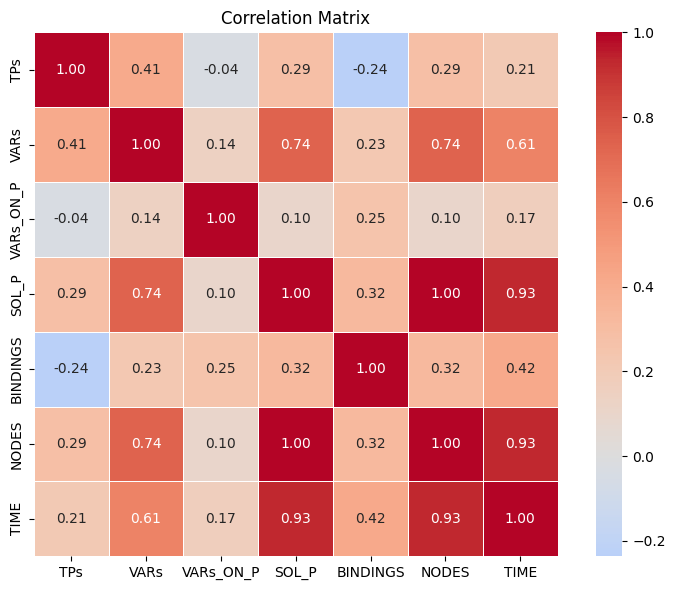

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "NODES", "TIME"]
corr = df[cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [20]:
corr = df[["TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "NODES", "TIME"]].corr()
print(corr.to_string(float_format="{:.2f}".format))

            TPs  VARs  VARs_ON_P  SOL_P  BINDINGS  NODES  TIME
TPs        1.00  0.41      -0.04   0.29     -0.24   0.29  0.21
VARs       0.41  1.00       0.14   0.74      0.23   0.74  0.61
VARs_ON_P -0.04  0.14       1.00   0.10      0.25   0.10  0.17
SOL_P      0.29  0.74       0.10   1.00      0.32   1.00  0.93
BINDINGS  -0.24  0.23       0.25   0.32      1.00   0.32  0.42
NODES      0.29  0.74       0.10   1.00      0.32   1.00  0.93
TIME       0.21  0.61       0.17   0.93      0.42   0.93  1.00


In [9]:
import pandas as pd

mem_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.startswith('MEM_') and f.endswith('.tsv')]

dfs = []
for file in mem_files:
    df_mem = pd.read_csv(file, sep='\t')
    dfs.append(df_mem)

all_mem = pd.concat(dfs, ignore_index=True)

# Clean %cpu column if it has '%' symbol
if '%cpu' in all_mem.columns:
    all_mem['%cpu'] = all_mem['%cpu'].astype(str).str.rstrip('%').astype(float)
    # Convert vsz from bytes to megabytes
    all_mem['vsz'] = all_mem['vsz'] / (1024 * 1024)
# Analyze %cpu and vsz
print("Descriptive statistics for %cpu:")
print(all_mem['%cpu'].describe())
print("\nDescriptive statistics for vsz:")
print(all_mem['vsz'].describe())

Descriptive statistics for %cpu:
count    82276.000000
mean       123.510761
std         48.061277
min          0.000000
25%        104.000000
50%        108.000000
75%        114.800000
max        472.000000
Name: %cpu, dtype: float64

Descriptive statistics for vsz:
count    82276.000000
mean        35.213418
std          0.617411
min          0.000000
25%         35.234009
50%         35.247673
75%         35.257412
max         35.292904
Name: vsz, dtype: float64


In [10]:
import os
err_files = [f for f in os.listdir(directory) if f.startswith("ERR_")]
non_empty_err_files = []
oom_err_files = []

for filename in err_files:
    filepath = os.path.join(directory, filename)
    with open(filepath, 'r', errors='ignore') as f:
        text = f.read()
    if text.strip():
        non_empty_err_files.append(filename)
        if "OutOfMemory" in text:
            oom_err_files.append(filename)

print("File ERR_ con contenuto testo:")
for f in non_empty_err_files:
    print(f)

print("\nFile ERR_ contenenti 'OutOfMemory':")
for f in oom_err_files:
    print(f)

File ERR_ con contenuto testo:
ERR_H_1_10_12_1_100000_csv_stream2.tsv
ERR_H_1_10_12_1_100000_csv_stream3.tsv
ERR_H_1_10_12_1_100000_csv_stream1.tsv

File ERR_ contenenti 'OutOfMemory':
ERR_H_1_10_12_1_100000_csv_stream2.tsv
ERR_H_1_10_12_1_100000_csv_stream3.tsv
ERR_H_1_10_12_1_100000_csv_stream1.tsv


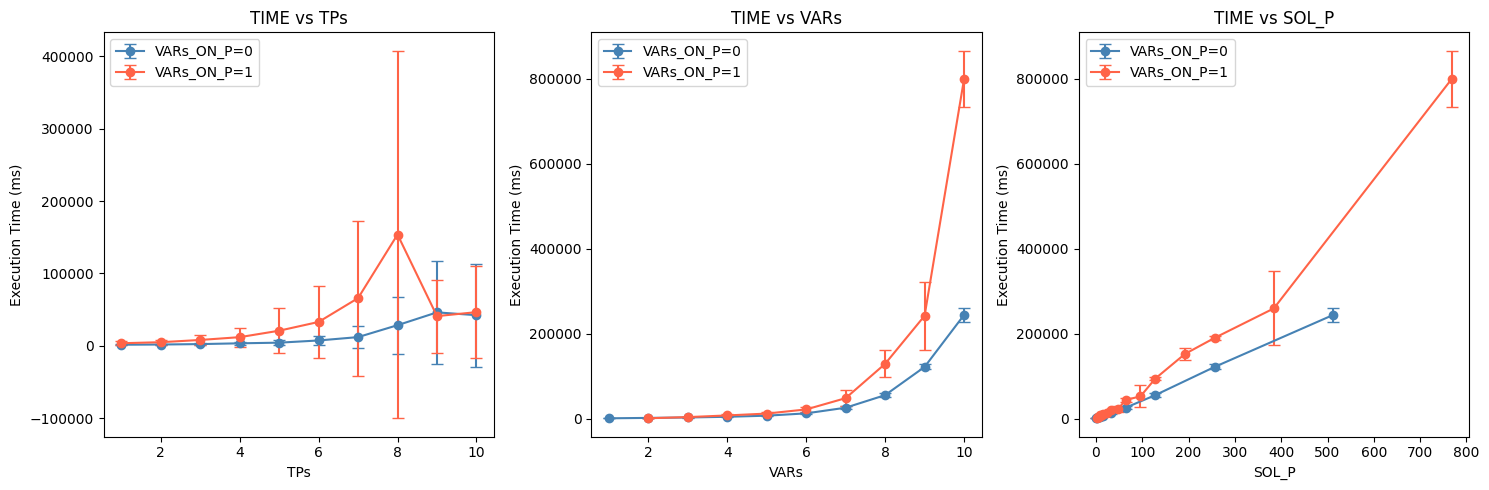

In [17]:
import matplotlib.pyplot as plt

factors = ["TPs", "VARs", "SOL_P"]
colors = {0: "steelblue", 1: "tomato"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, factor in zip(axes, factors):
    for var_on_p, group in df.groupby("VARs_ON_P"):
        stats = group.groupby(factor)["TIME"].agg(["mean", "std"]).reset_index()
        ax.errorbar(stats[factor], stats["mean"], yerr=stats["std"],
                    marker="o", capsize=4, color=colors[var_on_p],
                    label=f"VARs_ON_P={var_on_p}")
    ax.set_xlabel(factor)
    ax.set_ylabel("Execution Time (ms)")
    ax.set_title(f"TIME vs {factor}")
    ax.legend()

plt.tight_layout()
plt.show()